In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import minmax_scale

In [5]:
df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


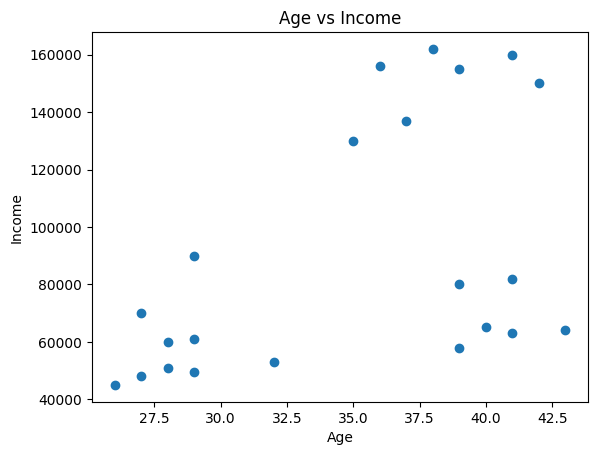

In [4]:
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()


Shape: (22, 3)


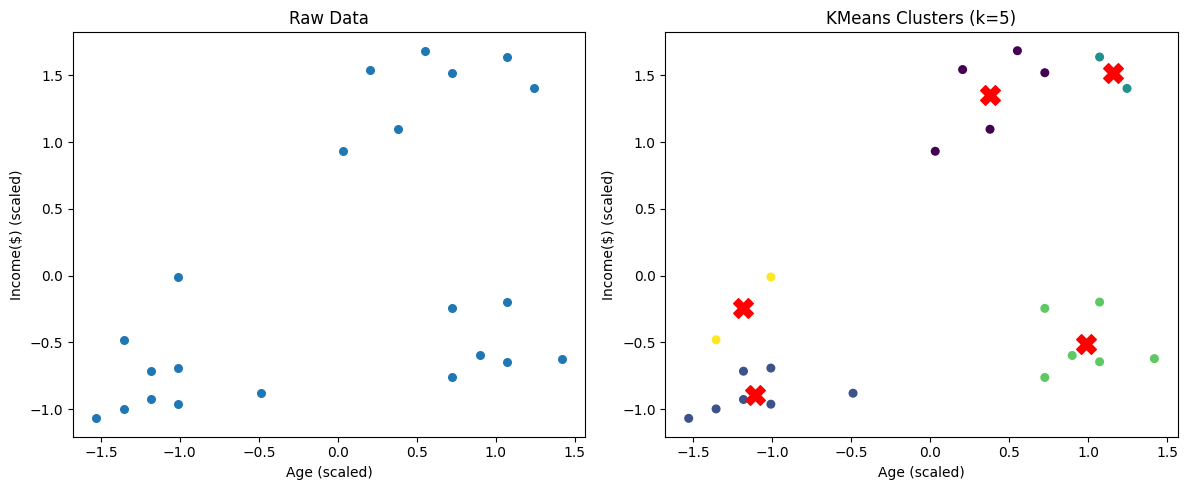

Inertia: 2.32
Iterations: 3


In [6]:
print(f"\nShape: {df.shape}")

X = df[['Age', 'Income($)']].values
X = StandardScaler().fit_transform(X)

kmeans =  KMeans(n_clusters=5 ,init='k-means++' ,n_init='auto' ,random_state=42)
kmeans.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], s=30)
axes[0].set_xlabel('Age (scaled)')
axes[0].set_ylabel('Income($) (scaled)')
axes[0].set_title('Raw Data')

axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=30)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200)
axes[1].set_xlabel('Age (scaled)')
axes[1].set_ylabel('Income($) (scaled)')
axes[1].set_title('KMeans Clusters (k=5)')

plt.tight_layout()
plt.show()

print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Iterations: {kmeans.n_iter_}")

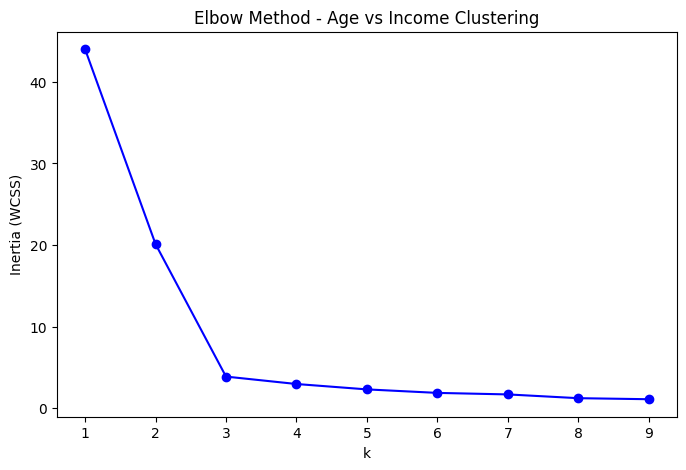

In [5]:
X = df[['Age','Income($)']].values
X = StandardScaler().fit_transform(X)

inertias = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method - Age vs Income Clustering')
plt.xticks(list(K))
plt.show()

In [7]:
km = KMeans(n_clusters=5)
y_pred = km.fit_predict(df[['Age', 'Income($)']])
y_pred

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 3, 3, 4, 4, 4, 4, 4, 0, 0, 0, 2, 2, 0])

In [8]:
df['Cluster'] = y_pred
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [9]:
km.cluster_centers_

array([[3.52857143e+01, 6.30000000e+04],
       [3.92000000e+01, 1.56600000e+05],
       [3.63333333e+01, 8.40000000e+04],
       [3.60000000e+01, 1.33500000e+05],
       [2.84000000e+01, 4.93000000e+04]])

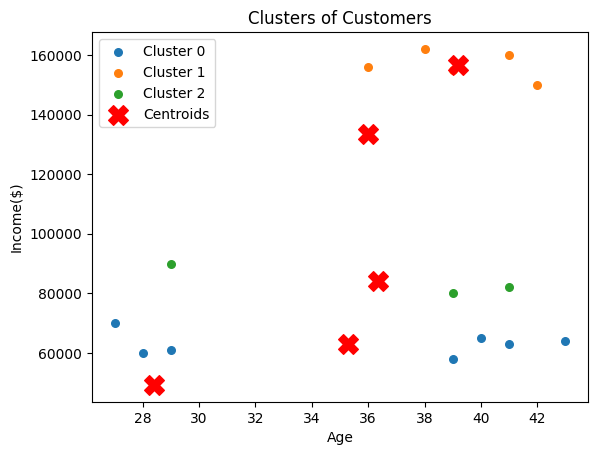

In [11]:
df1 = df[df['Cluster'] == 0]
df2 = df[df['Cluster'] == 1]
df3 = df[df['Cluster'] == 2]
plt.scatter(df1['Age'], df1['Income($)'], s=30, label='Cluster 0')
plt.scatter(df2['Age'], df2['Income($)'], s=30, label='Cluster 1')
plt.scatter(df3['Age'], df3['Income($)'], s=30, label='Cluster 2')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.title('Clusters of Customers')
plt.legend()
plt.show()